In [23]:
import sys
sys.path.append("..")

import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import numpy as np
import os

def plot_histogram(data, title, xlabel, use_log=False):
    num_bins = 50
    data = np.asarray(data)
    data = data[np.isfinite(data)]
    if use_log:
        data = data[data > 0]

    xmin, xmax = data.min(), data.max()
    mean, median, std = data.mean(), np.median(data), data.std()
    print(f"{xlabel}: Min: {xmin}, Max: {xmax}, Mean: {mean}, Median: {median}, Std: {std}")

    def format_tick(x):
        return f"{x:.2e}" if abs(x) < 1e-3 or abs(x) > 1e4 else f"{x:.3g}"

    available = {f.name for f in fm.fontManager.ttflist}
    font_pref = next(
        (f for f in ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"] if f in available),
        "sans-serif"
    )
    plt.rcParams.update({
        "font.family": font_pref,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

    fig, ax = plt.subplots(figsize=(15, 8))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # ── Histogram ─────────────────────────────────────────────────────
    BAR_COLOR = "#5C6BC0"
    if use_log:
        bins = np.logspace(np.log10(xmin), np.log10(xmax), num_bins + 1)
        n, bins_out, patches = ax.hist(
            data, bins=bins, color=BAR_COLOR, edgecolor="white", linewidth=0.5, alpha=0.88
        )
        ax.set_xscale("log")
        ticks = np.geomspace(xmin, xmax, 6)
        x_label_str = f"{xlabel} (log scale)"
    else:
        n, bins_out, patches = ax.hist(
            data, bins=num_bins, color=BAR_COLOR, edgecolor="white", linewidth=0.5, alpha=0.88
        )
        ticks = np.linspace(xmin, xmax, 6)
        x_label_str = xlabel

    cv = n.std() / n.mean() if n.mean() > 0 else 0
    if cv > 0.05:
        norm_c = plt.Normalize(n.min(), n.max())
        cmap = plt.cm.Blues
        for count, patch in zip(n, patches):
            patch.set_facecolor(cmap(0.45 + 0.45 * norm_c(count)))
            patch.set_edgecolor("white")
            patch.set_linewidth(0.5)

    # ── Axes & ticks ──────────────────────────────────────────────────
    ticks = np.unique(np.concatenate(([xmin], ticks, [xmax])))
    ax.set_xlim(xmin, xmax)
    ax.set_xticks(ticks)
    ax.set_xticklabels(
        [format_tick(t) for t in ticks],
        rotation=30, ha="right", fontsize=13, color="#555"
    )
    ax.set_ylabel("Count", labelpad=12, fontsize=14, color="#444")
    ax.set_xlabel(x_label_str, labelpad=12, fontsize=14, color="#444")
    ax.yaxis.set_tick_params(labelsize=13, labelcolor="#555")
    ax.spines["left"].set_color("#DDDDDD")
    ax.spines["bottom"].set_color("#DDDDDD")

    # ── Grid ──────────────────────────────────────────────────────────
    ax.grid(True, which="both" if use_log else "major",
            axis="y", color="#EEEEEE", linewidth=1.2, zorder=0)
    ax.set_axisbelow(True)

    # ── Min / Max markers ─────────────────────────────────────────────
    # yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
    # for val in [xmin, xmax]:
    #     ax.axvline(val, color="#CC4444", linestyle="--", linewidth=1.1, alpha=0.7, zorder=3)
    # ax.text(xmin, ax.get_ylim()[0] - yrange * 0.06, f"min  {format_tick(xmin)}",
    #         ha="left", va="top", fontsize=11, color="#CC4444",
    #         transform=ax.transData, clip_on=False)
    # ax.text(xmax, ax.get_ylim()[0] - yrange * 0.06, f"max  {format_tick(xmax)}",
    #         ha="right", va="top", fontsize=11, color="#CC4444",
    #         transform=ax.transData, clip_on=False)

    # ── Mean / Median lines — no floating labels ───────────────────────
    # ax.axvline(mean,   color="#1E88E5", linestyle="-",  linewidth=1.6, alpha=0.9, zorder=4)
    # ax.axvline(median, color="#43A047", linestyle="--", linewidth=1.6, alpha=0.9, zorder=4)

    # ── Stats box — OUTSIDE the axes, right of the plot ───────────────
    # Fixed-width monospace labels to align columns perfectly
    stats_lines = [
        ("mean",   format_tick(mean)),
        ("median", format_tick(median)),
        ("std",    format_tick(std)),
        ("n",      f"{len(data):,}"),
    ]
    # Build the text with explicit tab-like spacing using ljust
    col_w = max(len(k) for k, v in stats_lines) + 2
    stats_text = "\n".join(f"{k.ljust(col_w)}{v.rjust(10)}" for k, v in stats_lines)

    ax.text(
        1.02, 1.0, stats_text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11, color="#333",
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="#DDDDDD", lw=0.8)
    )

    # ── Legend outside, below the stats box ───────────────────────────
    from matplotlib.lines import Line2D
    # legend_elements = [
    #     Line2D([0], [0], color="#1E88E5", linestyle="-",  linewidth=2, label="mean"),
    #     Line2D([0], [0], color="#43A047", linestyle="--", linewidth=2, label="median"),
    #     Line2D([0], [0], color="#CC4444", linestyle="--", linewidth=1.5, label="min / max"),
    # ]
    # ax.legend(
    #     handles=legend_elements,
    #     loc="upper left",
    #     bbox_to_anchor=(1.02, 0.72),
    #     frameon=True,
    #     framealpha=0.95,
    #     edgecolor="#DDDDDD",
    #     fontsize=11,
    #     handlelength=2,
    #     handletextpad=0.8,
    #     borderpad=0.7,
    #     labelspacing=0.6,
    # )

    # ── Title ─────────────────────────────────────────────────────────
    ax.set_title(title, fontsize=15, fontweight="normal", color="#1A1A1A",
                 pad=18, loc="center", fontfamily=font_pref)

    fig.tight_layout(pad=1.8)
    # Make room for the right-side panel
    fig.subplots_adjust(right=0.82)
    plt.show()

def load_and_plot_amp_snr(file_path):
    params = {}
    with h5py.File(file_path, "r") as f:
        for key, value in f['params'].items():
            if key in ["amp", "snr"]:
                params[key] = value[:]

    min_amp = params['amp'].min()
    max_amp = params['amp'].max()
    size = params['amp'].shape[0]

    plot_histogram(params['amp'], f"Dataset Size {size}, Amplitude Min: {min_amp:.2e}, Amplitude Max: {max_amp:.2e} - Distribution of Amplitude", "Amplitude", use_log=False)
    plot_histogram(params['snr'], f"Dataset Size {size}, Amplitude Min: {min_amp:.2e}, Amplitude Max: {max_amp:.2e} - Distribution of SNR", "SNR", use_log=False)

In [ ]:
file_path = "../data/synthetic_dataset/dataset_8M_2.0e-23_1.5e-22_filtering_True_10_100_difficulty_1/dataset.hdf5"
load_and_plot_amp_snr(file_path)

In [ ]:
file_path = "../data/synthetic_dataset/dataset_3M_2.0e-23_1.0e-22_filtering_True_10_100_difficulty_1/dataset.hdf5" # Keys : 'params', 'waveforms' 
load_and_plot_amp_snr(file_path)

In [ ]:
file_path = "../data/synthetic_dataset/dataset_3M_5.0e-24_2.0e-22_filtering_True_5_150_difficulty_1/dataset.hdf5"
load_and_plot_amp_snr(file_path)

Amplitude: Min: 7.768643030048633e-24, Max: 1.7999898707019027e-22, Mean: 6.902185821885556e-23, Median: 6.609077926119085e-23, Std: 3.743392066509216e-23


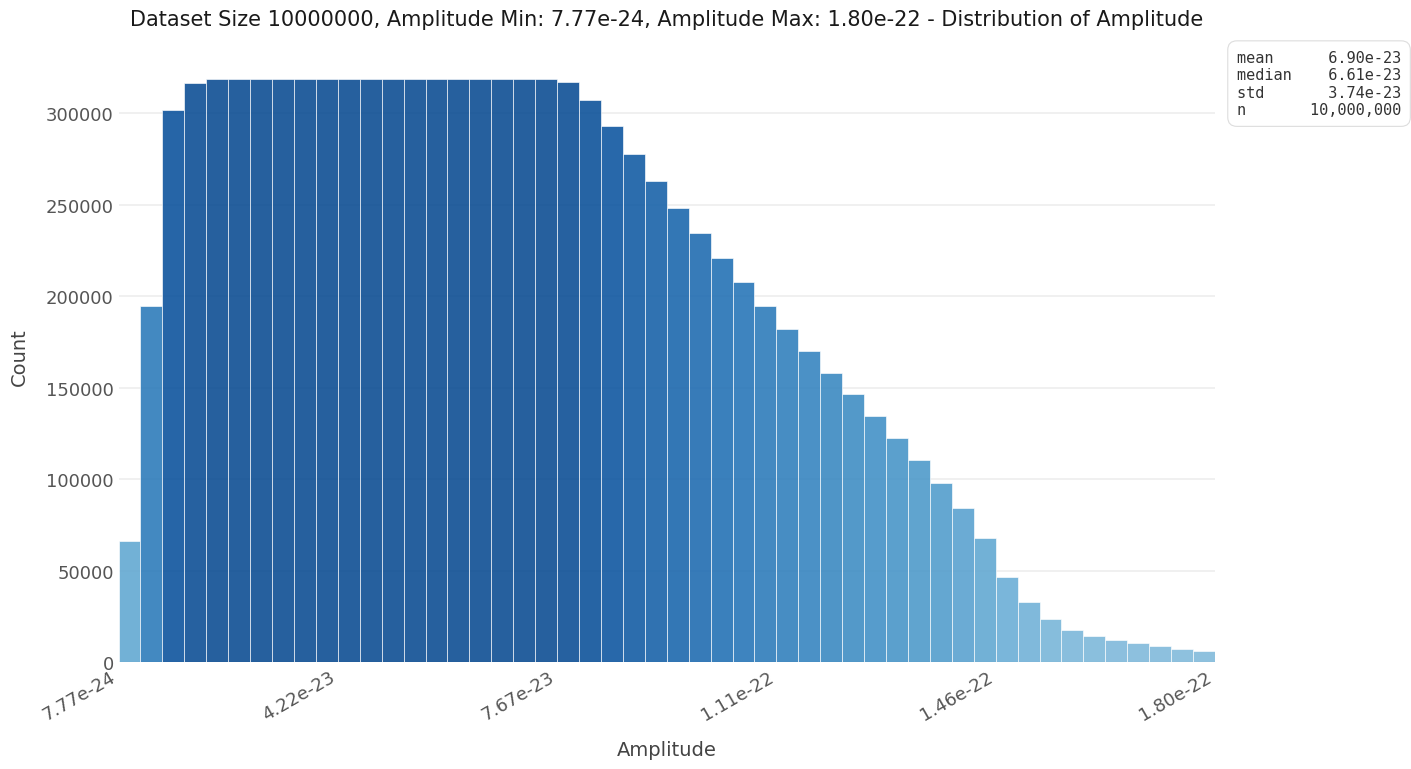

SNR: Min: 10.000003814697266, Max: 99.99999237060547, Mean: 54.91359329223633, Median: 54.903724670410156, Std: 25.941747665405273


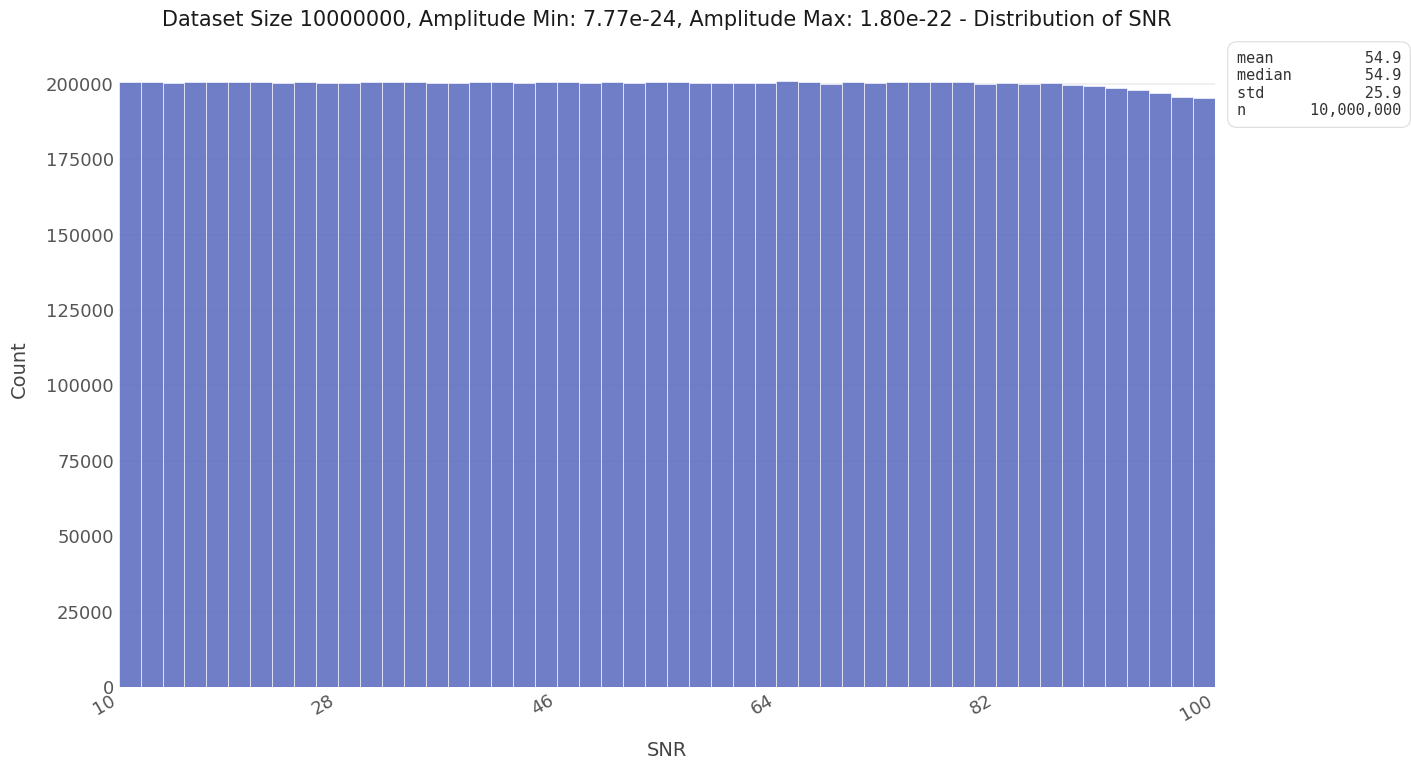

In [24]:
file_path = "../data/synthetic_dataset/dataset_10M_uniform_SNR_10_100/dataset.hdf5"
load_and_plot_amp_snr(file_path)

Amplitude: Min: 7.797913713936858e-24, Max: 1.7999874725647508e-22, Mean: 6.902732975809417e-23, Median: 6.609485609434903e-23, Std: 3.743392066509216e-23


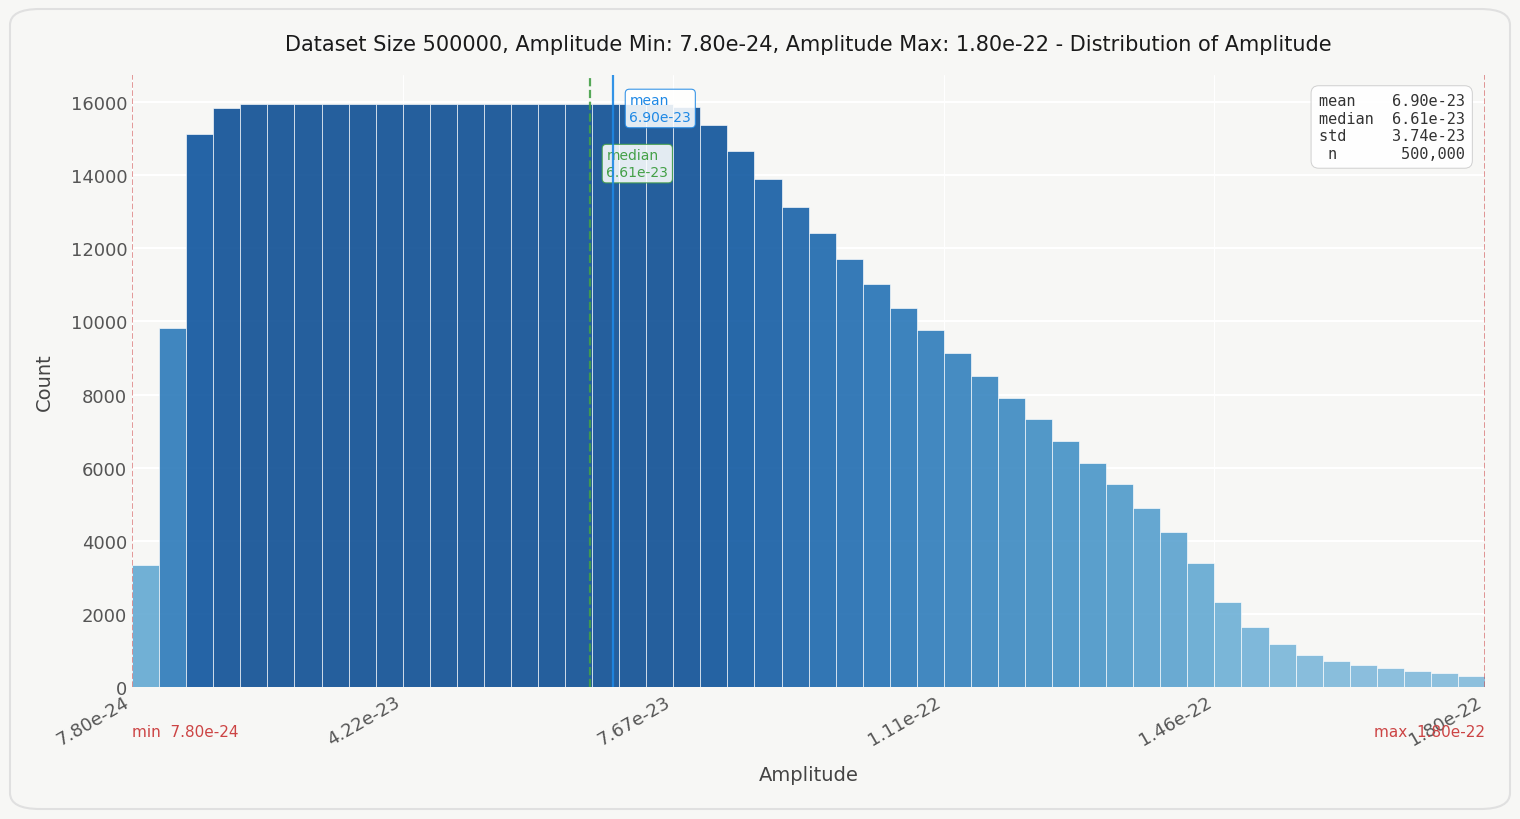

SNR: Min: 10.00024127960205, Max: 99.99986267089844, Mean: 54.91660690307617, Median: 54.90376281738281, Std: 25.942684173583984


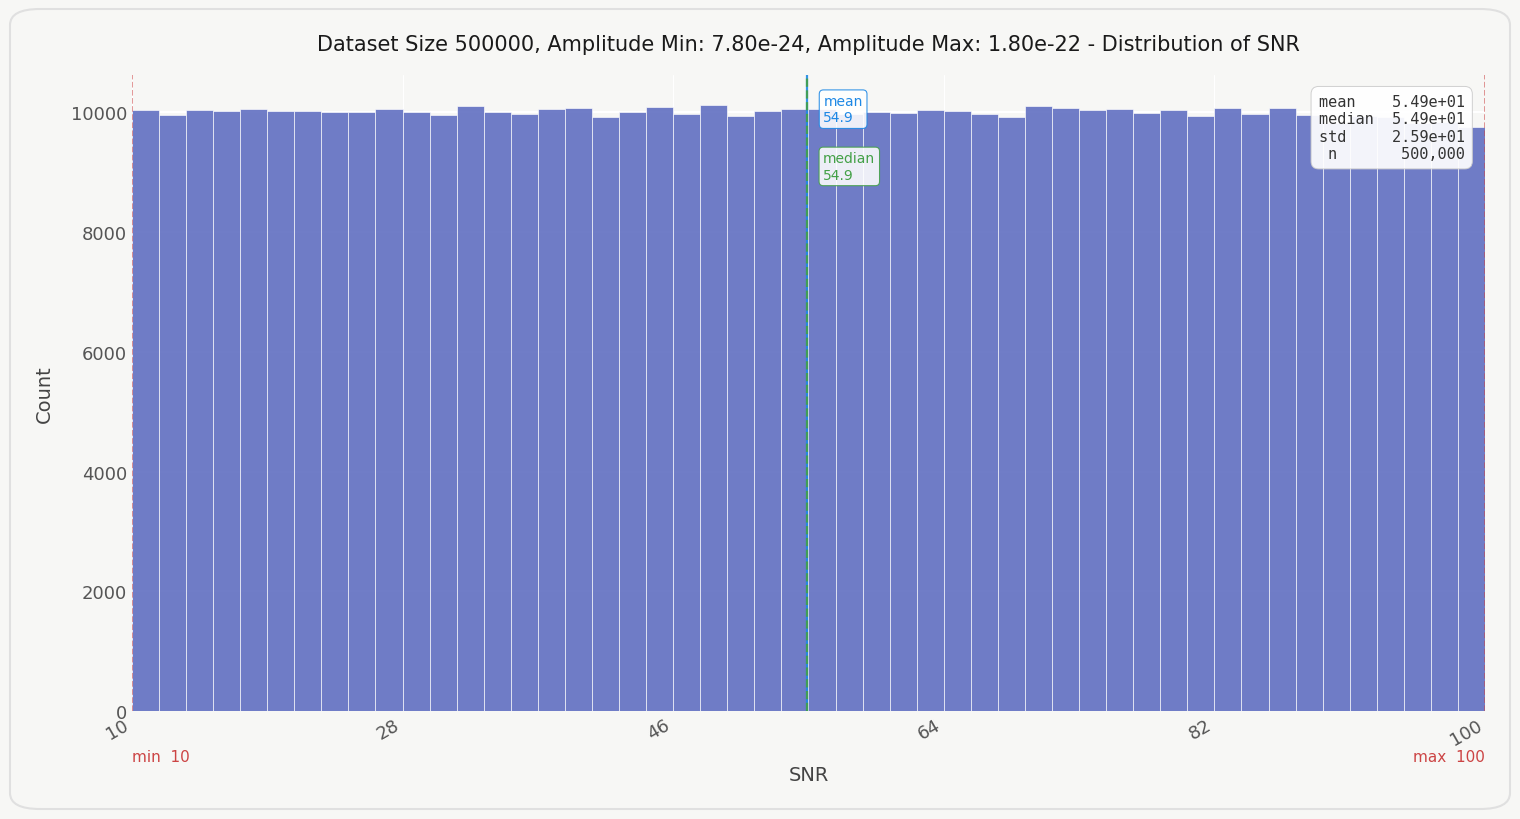

In [13]:
file_path = "../data/synthetic_dataset/dataset_500K_uniform_SNR_10_100/dataset.hdf5"
load_and_plot_amp_snr(file_path)